In [ ]:
import os
import tifffile
import matplotlib.pyplot as plt
import numpy as np
import torch
from models.skip1d import*
from tqdm.notebook import tqdm
import time
from matplotlib.patches import Rectangle
import h5py

device = 'cpu'
torch.set_default_dtype(torch.float32)


# voltage imaging data
# base_path = "E:\\Voltron2_part1\\Voltron_Cell1"

# tif_file = next((f for f in os.listdir(base_path) if f.endswith(".tif")), None)

# tif_path = os.path.join(base_path, tif_file)

# # Read TIFF file
# vol_data = tifffile.imread(tif_path)  # shape: (T, H, W) or (H, W)


# calcium imaging data
base_path_noisy = r"E:\\bma22_epm_motioncorrected_round1_cropped_correction.mat"

with h5py.File(base_path_noisy, 'r') as mat_data:
    print("Available keys in .mat file:", list(mat_data.keys()))

    
    dataset = mat_data['Y']
    data_array = dataset[()]
    vol_data = data_array.astype(np.float32)


# Normalize the full video globally
full_video = torch.tensor(vol_data.astype(np.float32), dtype=torch.float32)
mean_val = full_video.mean()
std_val = full_video.std()

full_video_norm = (full_video - mean_val) / std_val

# Subsample 200 frames
video_tensor = full_video_norm[1000:1200]

# video_tensor = full_video_norm[:, ]

H, W, T = video_tensor.shape[1], video_tensor.shape[2], video_tensor.shape[0]

rank_H = 48
rank_W = 48
rank_T = 72
epochs = 500
learning_rate = 1e-4

# h_inp = nn.Parameter(torch.randn(1, rank_H, H))
# w_inp = nn.Parameter(torch.randn(1, rank_W, W))
# t_inp = nn.Parameter(torch.randn(1, rank_T, T))

h_inp = get_1d_posencode_inp(H, rank_H//2)
w_inp = get_1d_posencode_inp(W, rank_W//2)
t_inp = get_1d_posencode_inp(T, rank_T//2)

# Define parameters for skip1d
skip_n33d = 128  # Number of channels in the downsampling path
skip_n33u = 128  # Number of channels in the upsampling path
skip_n11 = 4   # Number of channels in the skip connection
num_scales = 5  # Number of scales in the skip connection
upsample_mode = 'linear'  # Upsampling mode
downsample_mode = 'stride'  # Downsampling mode
pad = 'reflection'  # Padding mode
act_fun = 'LeakyReLU'  # Activation function
filter_size_up=3
filter_size_down=3 
filter_size_skip=1


h_net = skip1d(
    rank_H,                       # Dimensionality of positional encoding (e.g., 32)
    rank_H,                       # Output dimensionality = Tucker rank (e.g., 32)
    num_channels_down = [skip_n33d]*num_scales if isinstance(skip_n33d, int) else skip_n33d,
    num_channels_up   = [skip_n33u]*num_scales if isinstance(skip_n33u, int) else skip_n33u,
    num_channels_skip = [skip_n11]*num_scales if isinstance(skip_n11, int) else skip_n11,
    upsample_mode     = upsample_mode,
    downsample_mode   = downsample_mode,
    need_sigmoid      = False,
    need_bias         = True,
    pad               = pad,
    act_fun           = act_fun,
    filter_size_up    = filter_size_up,
    filter_size_down  = filter_size_down,
    filter_skip_size  = filter_size_skip
)

w_net = skip1d(
    rank_W,                       # Dimensionality of positional encoding (e.g., 32)
    rank_W,                       # Output dimensionality = Tucker rank (e.g., 32)
    num_channels_down = [skip_n33d]*num_scales if isinstance(skip_n33d, int) else skip_n33d,
    num_channels_up   = [skip_n33u]*num_scales if isinstance(skip_n33u, int) else skip_n33u,
    num_channels_skip = [skip_n11]*num_scales if isinstance(skip_n11, int) else skip_n11,
    upsample_mode     = upsample_mode,
    downsample_mode   = downsample_mode,
    need_sigmoid      = False,
    need_bias         = True,
    pad               = pad,
    act_fun           = act_fun,
    filter_size_up    = filter_size_up,
    filter_size_down  = filter_size_down,
    filter_skip_size  = filter_size_skip
)

t_net = skip1d(
    rank_T,                       # Dimensionality of positional encoding (e.g., 32)
    rank_T,                       # Output dimensionality = Tucker rank (e.g., 32)
    num_channels_down = [skip_n33d]*num_scales if isinstance(skip_n33d, int) else skip_n33d,
    num_channels_up   = [skip_n33u]*num_scales if isinstance(skip_n33u, int) else skip_n33u,
    num_channels_skip = [skip_n11]*num_scales if isinstance(skip_n11, int) else skip_n11,
    upsample_mode     = upsample_mode,
    downsample_mode   = downsample_mode,
    need_sigmoid      = False,
    need_bias         = True,
    pad               = pad,
    act_fun           = act_fun,
    filter_size_up    = filter_size_up,
    filter_size_down  = filter_size_down,
    filter_skip_size  = filter_size_skip
)

# Switch to trairning mode
h_net.train()
w_net.train()
t_net.train()

net_params = list(h_net.parameters()) + list(w_net.parameters()) + list(t_net.parameters())
inp_params = [h_inp] + [w_inp] + [t_inp]
params = net_params + inp_params

core = torch.nn.Parameter(torch.ones((rank_T, rank_H, rank_W), dtype=torch.float32) /
    (rank_T * rank_H * rank_W) ** 0.5)
params += [core]

criterion_l1 = L2Norm()
    
loss_array = np.zeros(epochs)
mse_array = np.zeros(epochs)    
time_array = np.zeros(epochs)

optimizer = torch.optim.Adam(lr=learning_rate, params=params)
    
# Create a learning scheduler
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size= epochs)

u_inp_per = h_inp.detach().clone()
v_inp_per = w_inp.detach().clone()
w_inp_per = t_inp.detach().clone()

best_loss = float('inf')
best_epoch = 0
tic = time.time()

tbar = tqdm(range(epochs))

frame_idx = 100  # Example frame index to visualize
x, y = 36, 109      # top-left corner (column, row)
width, height = 20, 15

def plot_frame_with_rectangle(frame, x, y, width, height):
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(frame, cmap='hot')
    
    # Add rectangle patch
    rect = Rectangle((x, y), width, height, linewidth=2, edgecolor='b', facecolor='none')
    ax.add_patch(rect)

    ax.set_title(f"Rectangle at ({x}, {y}), w={width}, h={height}")
    plt.grid(False)
    plt.axis('off')
    plt.show()

loss_array = np.zeros(epochs)

for idx in tbar:
    A_h = h_net(h_inp).squeeze(0).permute(1, 0)  # [H, 32]
    A_w = w_net(w_inp).squeeze(0).permute(1, 0)  # [W, 32]
    A_t = t_net(t_inp).squeeze(0).permute(1, 0)  # [T, 32]

    # recon = torch.einsum('tr,hr,wr,rxy->thw', A_t, A_h, A_w, core)  # (T,H,W)

    # 1. Multiply along temporal mode (mode-0)
    out = torch.einsum('tr, rhw -> thw', A_t, core)      # [T, R_H, R_W]

    # 2. Multiply along spatial height (mode-1)
    out = torch.einsum('trw, hr -> t w h', out, A_h)     # [T, H, R_W]

    # 3. Multiply along spatial width (mode-2)
    recon = torch.einsum('trh, wr -> thw', out, A_w)     # [T, H, W]

    loss = criterion_l1(video_tensor - recon)

    # Track metrics
    loss_array[idx] = loss.item()
    time_array[idx] = time.time() - tic

    if loss.item() < best_loss:
        best_loss = loss.item()
        best_epoch = idx
        best_reconstruction = recon.detach().clone()

    # Backprop
    optimizer.zero_grad()
    torch.autograd.set_detect_anomaly(True)
    loss.backward()
    optimizer.step()
    scheduler.step()  # optional

    loss_array[idx] = loss.item()

    # Optionally visualize or print
    if idx % 10 == 0:
        print(f'Epoch {idx:4d} | loss {loss.item():.4e}')
    
    if idx % 50 == 0 or idx == 0:
        recon_scaled = recon* std_val + mean_val
        video_scaled = video_tensor * std_val + mean_val
        recon_frame = recon_scaled[frame_idx].detach().cpu().numpy()
        gt_frame = video_scaled[frame_idx].detach().cpu().numpy()

        diff_frame = np.abs(gt_frame - recon_frame)
        diff_frame_signed = gt_frame - recon_frame

        fig, axs = plt.subplots(1, 4, figsize=(12, 4))
        axs[0].imshow(gt_frame, cmap='hot')
        axs[0].set_title('Noisy Input Frame')
        axs[0].axis('off')

        axs[1].imshow(recon_frame, cmap='hot')
        axs[1].set_title('Reconstructed Frame')
        axs[1].axis('off')

        axs[2].imshow(diff_frame, cmap='hot')
        axs[2].set_title('Abs Difference')
        axs[2].axis('off')

        axs[3].imshow(diff_frame_signed, cmap='hot')
        axs[3].set_title('Signed Difference')
        axs[3].axis('off')

        plt.suptitle(f'Epoch {idx}')
        plt.tight_layout()
        plt.show()

        plot_frame_with_rectangle(gt_frame, x, y, width, height)

        # Extract the patch over time (shape: T x height x width)
        patch_noisy = video_scaled[:, y:y+height, x:x+width]  # shape: (T, h, w)
        patch_recon = recon_scaled[:, y:y+height, x:x+width]

        # Average over spatial dimensions
        avg_trace_noisy = patch_noisy.mean(dim=(1, 2)).detach().cpu().numpy()
        avg_trace_recon = patch_recon.mean(dim=(1, 2)).detach().cpu().numpy()

        # Plot the time trace
        plt.figure(figsize=(10, 4))
        plt.plot(avg_trace_noisy, label='Noisy Mean Intensity in  ROI', alpha=0.6)
        plt.plot(avg_trace_recon, label='Reconstructed Mean Intensity in ROI', color='orange')
        plt.xlabel("Time (frames)")
        plt.ylabel("Average Intensity")
        plt.title(f"Time Trace for ROI at ({x}, {y}), w={width}, h={height}")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

#plot loss
plt.figure(figsize=(10, 4))
plt.plot(loss_array, label='Loss', color='blue')
plt.xlabel("Epoch")
plt.ylabel("Loss Value")
plt.title("Training Loss Over Epochs")


Available keys in .mat file: ['Y', 'Ysiz']


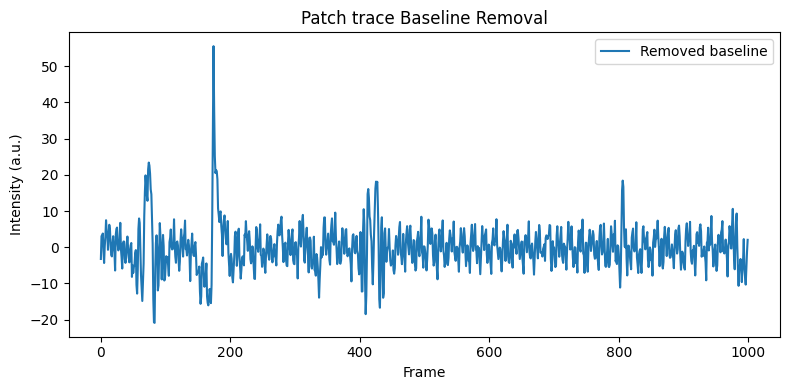

In [7]:
from scipy.ndimage import uniform_filter1d

baseline = np.zeros_like(video_scaled)
for i in range(H):
    for j in range(W):
        baseline[:, i, j] = uniform_filter1d(video_scaled[:, i, j], size=61, mode='nearest')

baseline_torch = torch.from_numpy(baseline)

activity = baseline_torch - video_scaled

neuron = activity[:,y:y+height, x:x+width]

trace = neuron.mean(dim=(1, 2))

plt.figure(figsize=(8, 4))
plt.plot(trace, label='Removed baseline')
plt.title(f'Patch trace Baseline Removal')
plt.xlabel('Frame')
plt.ylabel('Intensity (a.u.)')
plt.legend()
plt.tight_layout()
plt.show()

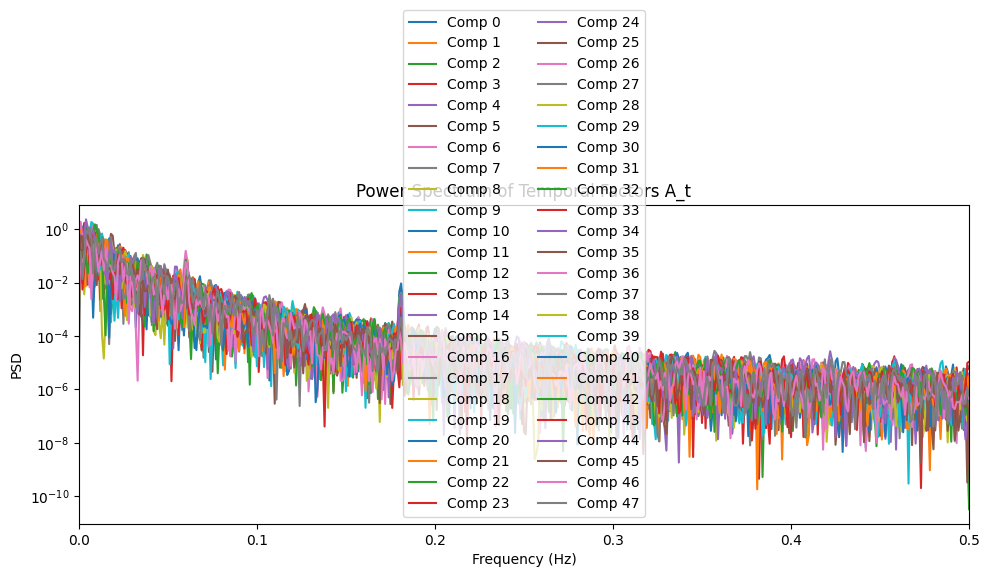

In [8]:
from scipy.signal import welch

if isinstance(A_t, torch.Tensor):
    A_t = A_t.detach().cpu().numpy()

T, r_t = A_t.shape
plt.figure(figsize=(10, 5))
for i in range(r_t):
    f, Pxx = welch(A_t[:, i], fs=1, nperseg=min(2048, T))
    plt.semilogy(f, Pxx, label=f'Comp {i}')
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD")
plt.title("Power Spectrum of Temporal Factors A_t")
plt.legend(ncol=2)
plt.xlim(0, 0.5)
plt.tight_layout()
plt.show()

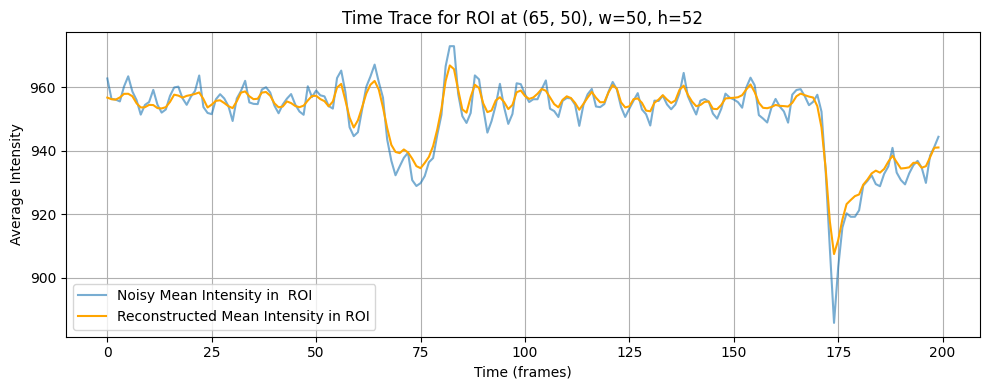

In [3]:
avg_trace_noisy_200 = avg_trace_noisy[:200]
avg_trace_recon_200 = avg_trace_recon[:200] 

# Plot the time trace
plt.figure(figsize=(10, 4))
plt.plot(avg_trace_noisy_200, label='Noisy Mean Intensity in  ROI', alpha=0.6)
plt.plot(avg_trace_recon_200, label='Reconstructed Mean Intensity in ROI', color='orange')
plt.xlabel("Time (frames)")
plt.ylabel("Average Intensity")
plt.title(f"Time Trace for ROI at ({x}, {y}), w={width}, h={height}")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Best epoch: 708, Best loss: 5.6977e-02


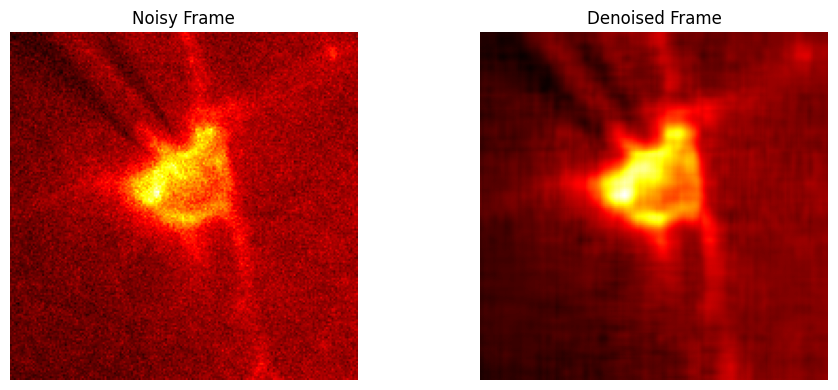

In [5]:
import matplotlib.pyplot as plt


frame_idx = 100  # or any frame you want to inspect

# Rescale back the denoised video from normalized form
best_reconstruction_rescaled = best_reconstruction * std_val + mean_val
noisy_video_rescaled = video_tensor * std_val + mean_val

print(f"Best epoch: {best_epoch}, Best loss: {best_loss:.4e}")

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(noisy_video_rescaled[frame_idx].cpu(), cmap='hot')
plt.title("Noisy Frame")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(best_reconstruction_rescaled[frame_idx].cpu(), cmap='hot')
plt.title("Denoised Frame")
plt.axis('off')

plt.tight_layout()
plt.show()

In [2]:
import matplotlib.pyplot as plt


frame_idx = 100
x, y = 50, 93

plt.figure(figsize=(5, 5))
plt.imshow(noisy_video_rescaled[frame_idx].cpu(), cmap='hot')
plt.scatter([y], [x], c='cyan', marker='x', s=100, label=f'Pixel ({x},{y})')
plt.title(f"Noisy Frame {frame_idx} with Pixel Marker")
plt.axis('off')
plt.legend()
plt.show()

raw_trace = video_tensor[:, x, y] * std_val + mean_val
denoised_trace = best_reconstruction[:, x, y] * std_val + mean_val

plt.figure(figsize=(10, 4))
plt.plot(raw_trace.cpu(), label='Noisy', color='gray', alpha=0.6)
plt.plot(denoised_trace.cpu(), label='Denoised', color='orange')
plt.xlabel('Frame (Time)')
plt.ylabel('Fluorescence Intensity')
plt.title(f"Temporal Trace at Pixel ({x}, {y})")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

NameError: name 'noisy_video_rescaled' is not defined

<Figure size 500x500 with 0 Axes>

  0%|          | 0/500 [00:00<?, ?it/s]

Epoch    0 | loss 1.0001e+00


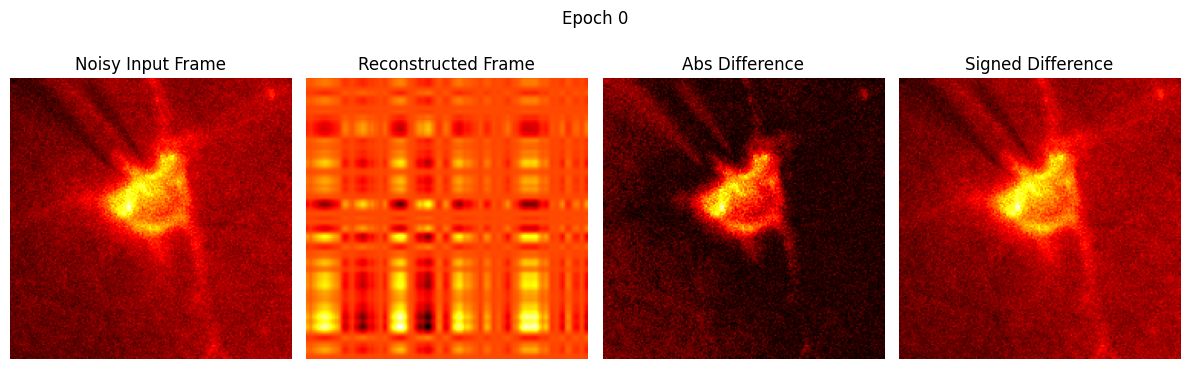

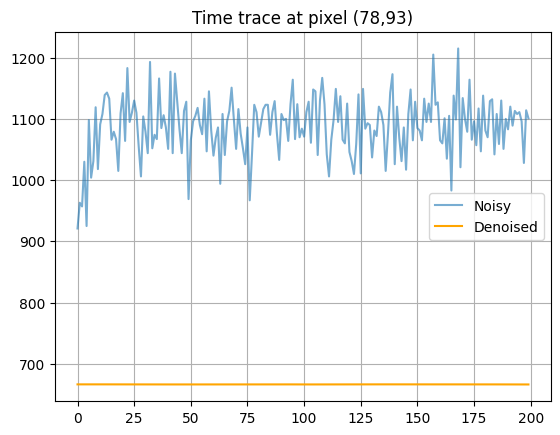

Epoch   10 | loss 2.5322e-01
Epoch   20 | loss 1.6035e-01
Epoch   30 | loss 1.3167e-01
Epoch   40 | loss 1.2023e-01
Epoch   50 | loss 1.1485e-01
Epoch   60 | loss 1.1147e-01
Epoch   70 | loss 1.0930e-01
Epoch   80 | loss 1.0774e-01
Epoch   90 | loss 1.0642e-01
Epoch  100 | loss 1.0535e-01


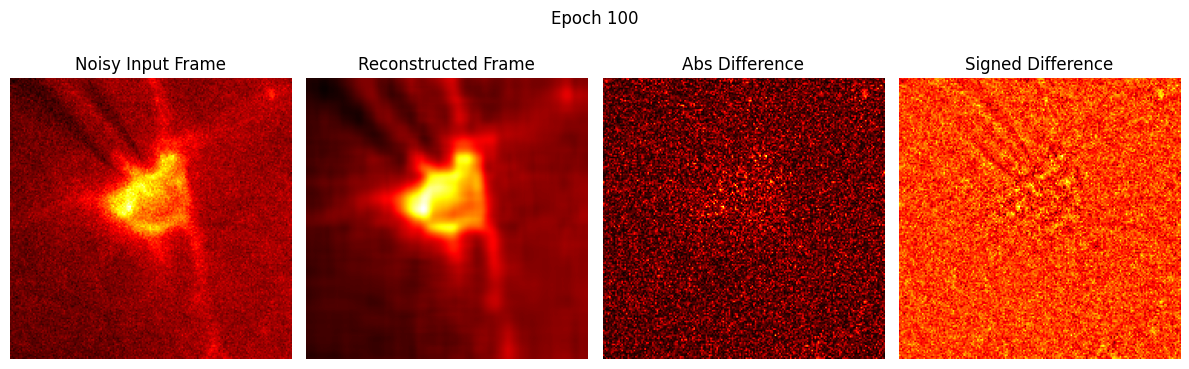

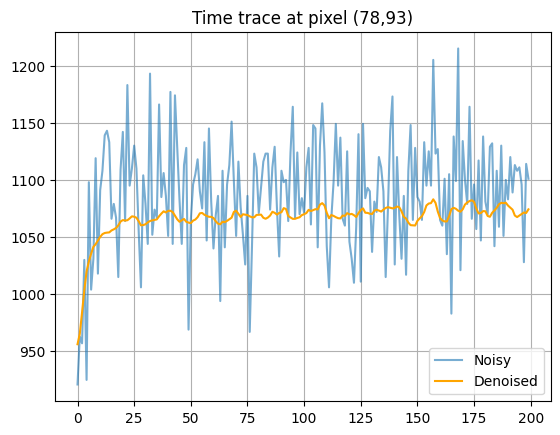

Epoch  110 | loss 1.0444e-01
Epoch  120 | loss 1.0368e-01
Epoch  130 | loss 1.0300e-01
Epoch  140 | loss 1.0240e-01
Epoch  150 | loss 1.0187e-01
Epoch  160 | loss 1.0139e-01
Epoch  170 | loss 1.0096e-01
Epoch  180 | loss 1.0058e-01
Epoch  190 | loss 1.0049e-01
Epoch  200 | loss 1.0216e-01


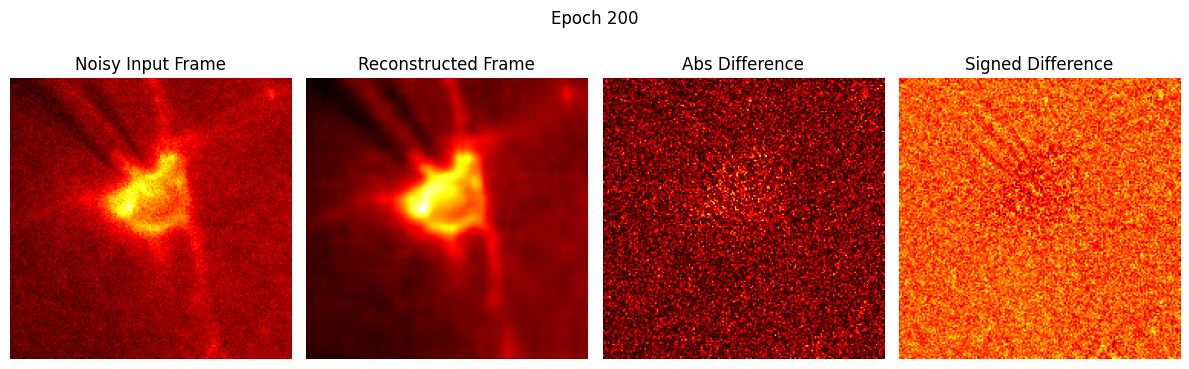

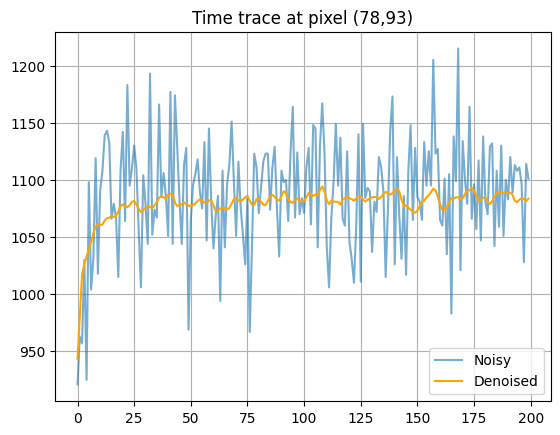

Epoch  210 | loss 1.0052e-01
Epoch  220 | loss 9.9973e-02
Epoch  230 | loss 9.9505e-02
Epoch  240 | loss 9.9240e-02
Epoch  250 | loss 9.9054e-02
Epoch  260 | loss 9.8884e-02
Epoch  270 | loss 9.8719e-02
Epoch  280 | loss 9.8634e-02
Epoch  290 | loss 9.8493e-02
Epoch  300 | loss 9.8342e-02


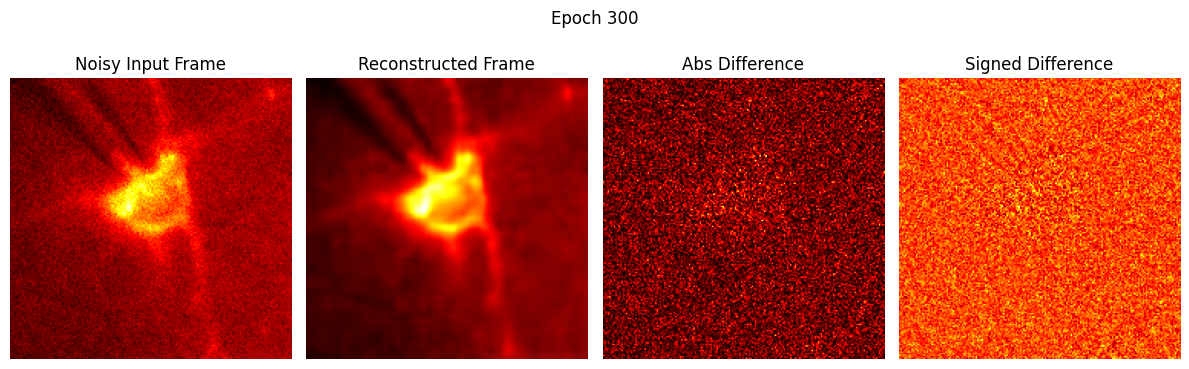

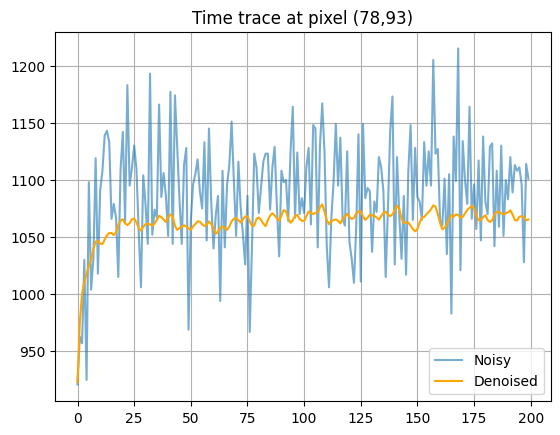

Epoch  310 | loss 9.8699e-02
Epoch  320 | loss 1.0083e-01
Epoch  330 | loss 9.9124e-02
Epoch  340 | loss 9.8128e-02
Epoch  350 | loss 9.7926e-02
Epoch  360 | loss 9.7888e-02
Epoch  370 | loss 9.7661e-02
Epoch  380 | loss 9.7554e-02
Epoch  390 | loss 9.7463e-02
Epoch  400 | loss 9.7435e-02


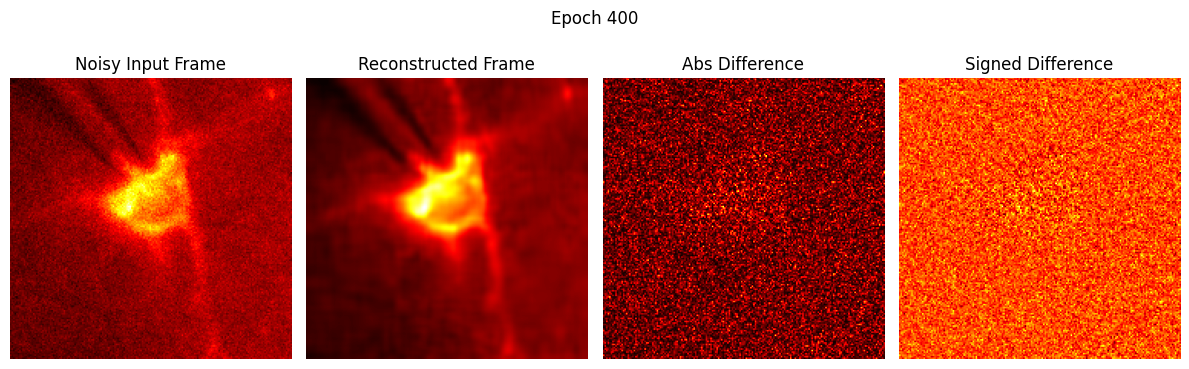

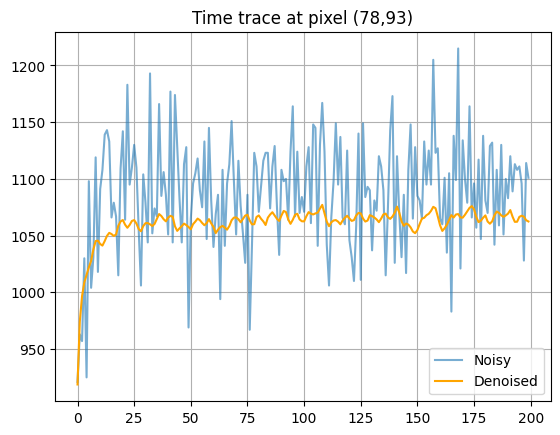

Epoch  410 | loss 9.9712e-02
Epoch  420 | loss 9.7930e-02
Epoch  430 | loss 9.7473e-02
Epoch  440 | loss 9.7223e-02
Epoch  450 | loss 9.7105e-02
Epoch  460 | loss 9.7010e-02
Epoch  470 | loss 9.6942e-02
Epoch  480 | loss 9.6979e-02
Epoch  490 | loss 1.0075e-01


SUPPORT Denoising:   0%|          | 0/200 [00:00<?, ?frame/s]

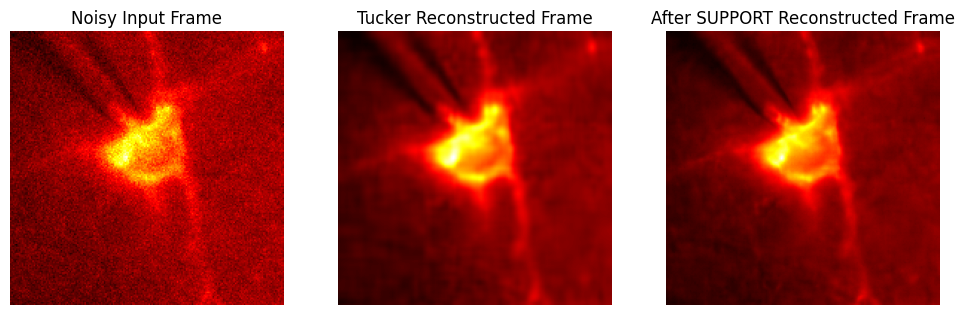

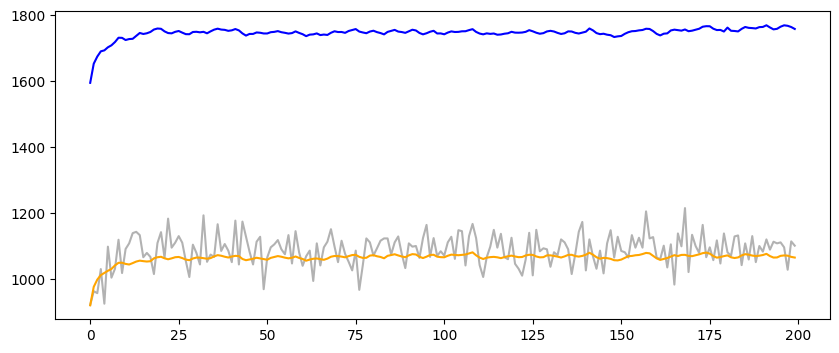

In [ ]:
import sys
import os
sys.path.append(os.path.join(os.getcwd(), "SUPPORT"))

from SUPPORT.model.SUPPORT import SUPPORT
from SUPPORT.src.utils.dataset_pyqt import DatasetSupport_test_stitch
import os
import tifffile
import matplotlib.pyplot as plt
import numpy as np
import torch
from models.skip1d import*
from tqdm.notebook import tqdm
import time

def load_support_model(model_path: str, bs_size: int = 1, use_cuda: bool = False):
    """
    Loads the pretrained SUPPORT model.

    Args:
        model_path (str): Path to the .pth model weights.
        bs_size (int): Blind spot size. Should match training setup (e.g., 1, 3, or 5).
        use_cuda (bool): Whether to load model on GPU.

    Returns:
        model (torch.nn.Module): The loaded and ready-to-use SUPPORT model.
    """
    # Define model architecture
    model = SUPPORT(
        in_channels=61,  # Temporal window
        mid_channels=[16, 32, 64, 128, 256],
        depth=5,
        blind_conv_channels=64,
        one_by_one_channels=[32, 16],
        last_layer_channels=[64, 32, 16],
        bs_size=bs_size,
    )

    # Load weights
    if use_cuda:
        model = model.cuda()
        state = torch.load(model_path)
    else:
        state = torch.load(model_path, map_location="cpu")

    model.load_state_dict(state)
    model.eval()  # Set to eval mode

    return model

def run_support_model_on_frame(residual_image, ti, support_model, mean_one, std_one, use_cuda=False):
    T, H, W = residual_image.shape
    img_one_tensor = torch.zeros(61, H, W)

    # Define temporal window
    start_idx = max(ti - 30, 0)
    end_idx = min(ti + 31, T)

    pad_front = max(30 - ti, 0)
    pad_end = max(31 - (T - ti), 0)

    img_one = residual_image[start_idx:end_idx]
    img_one_tensor[pad_front:61 - pad_end] = img_one

    if pad_front > 0:
        img_one_tensor[0:pad_front] = img_one_tensor[pad_front].repeat(pad_front, 1, 1)
    if pad_end > 0:
        img_one_tensor[61 - pad_end:] = img_one_tensor[61 - pad_end - 1].repeat(pad_end, 1, 1)

    # Patch extraction
    w = 128 if W > 128 else W
    h = 128 if H > 128 else H

    testset = DatasetSupport_test_stitch(
        img_one_tensor.clone().detach(),
        patch_size=[61, w, h],
        patch_interval=[1, w // 2, h // 2],
        mean_image=mean_one,
        std_image=std_one,
    )
    testloader = torch.utils.data.DataLoader(testset, batch_size=4)

    denoised_frame = np.zeros((1, H, W), dtype=np.float32)

    with torch.no_grad():
        for noisy_image, _, single_coordinate in testloader:
            if use_cuda:
                noisy_image = noisy_image.cuda()

            output = support_model(noisy_image)

            for bi in range(noisy_image.size(0)):
                s_h0 = int(single_coordinate["stack_start_h"][bi])
                s_h1 = int(single_coordinate["stack_end_h"][bi])
                p_h0 = int(single_coordinate["patch_start_h"][bi])
                p_h1 = int(single_coordinate["patch_end_h"][bi])
                s_w0 = int(single_coordinate["stack_start_w"][bi])
                s_w1 = int(single_coordinate["stack_end_w"][bi])
                p_w0 = int(single_coordinate["patch_start_w"][bi])
                p_w1 = int(single_coordinate["patch_end_w"][bi])

                denoised_frame[0, s_h0:s_h1, s_w0:s_w1] = (
                    output[bi].squeeze()[p_h0:p_h1, p_w0:p_w1].cpu()
                )

    return denoised_frame[0] * std_one + mean_one



#tucker
device = 'cpu'
torch.set_default_dtype(torch.float32)

base_path = "E:\\Voltron2_part1\\Voltron_Cell1"

tif_file = next((f for f in os.listdir(base_path) if f.endswith(".tif")), None)

tif_path = os.path.join(base_path, tif_file)

# Read TIFF file
vol_data = tifffile.imread(tif_path)  # shape: (T, H, W) or (H, W)

# Normalize the full video globally
full_video = torch.tensor(vol_data.astype(np.float32), dtype=torch.float32)
# mean_val = full_video.mean()
# std_val = full_video.std()

# full_video_norm = (full_video - mean_val) / std_val

# Subsample 200 frames
video_tensor = full_video[:200]
mean_val = video_tensor.mean()
std_val = video_tensor.std()
video_tensor = (video_tensor - mean_val) / std_val

H, W, T = video_tensor.shape[1], video_tensor.shape[2], video_tensor.shape[0]

rank_H = 48
rank_W = 48
rank_T = 72
epochs = 500
learning_rate = 1e-3

h_inp = get_1d_posencode_inp(H, rank_H//2)
w_inp = get_1d_posencode_inp(W, rank_W//2)
t_inp = get_1d_posencode_inp(T, rank_T//2)

# Define parameters for skip1d
skip_n33d = 128  # Number of channels in the downsampling path
skip_n33u = 128  # Number of channels in the upsampling path
skip_n11 = 4   # Number of channels in the skip connection
num_scales = 5  # Number of scales in the skip connection
upsample_mode = 'linear'  # Upsampling mode
downsample_mode = 'stride'  # Downsampling mode
pad = 'reflection'  # Padding mode
act_fun = 'LeakyReLU'  # Activation function
filter_size_up=3
filter_size_down=3 
filter_size_skip=1


h_net = skip1d(
    rank_H,                       # Dimensionality of positional encoding (e.g., 32)
    rank_H,                       # Output dimensionality = Tucker rank (e.g., 32)
    num_channels_down = [skip_n33d]*num_scales if isinstance(skip_n33d, int) else skip_n33d,
    num_channels_up   = [skip_n33u]*num_scales if isinstance(skip_n33u, int) else skip_n33u,
    num_channels_skip = [skip_n11]*num_scales if isinstance(skip_n11, int) else skip_n11,
    upsample_mode     = upsample_mode,
    downsample_mode   = downsample_mode,
    need_sigmoid      = False,
    need_bias         = True,
    pad               = pad,
    act_fun           = act_fun,
    filter_size_up    = filter_size_up,
    filter_size_down  = filter_size_down,
    filter_skip_size  = filter_size_skip
)

w_net = skip1d(
    rank_W,                       # Dimensionality of positional encoding (e.g., 32)
    rank_W,                       # Output dimensionality = Tucker rank (e.g., 32)
    num_channels_down = [skip_n33d]*num_scales if isinstance(skip_n33d, int) else skip_n33d,
    num_channels_up   = [skip_n33u]*num_scales if isinstance(skip_n33u, int) else skip_n33u,
    num_channels_skip = [skip_n11]*num_scales if isinstance(skip_n11, int) else skip_n11,
    upsample_mode     = upsample_mode,
    downsample_mode   = downsample_mode,
    need_sigmoid      = False,
    need_bias         = True,
    pad               = pad,
    act_fun           = act_fun,
    filter_size_up    = filter_size_up,
    filter_size_down  = filter_size_down,
    filter_skip_size  = filter_size_skip
)

t_net = skip1d(
    rank_T,                       # Dimensionality of positional encoding (e.g., 32)
    rank_T,                       # Output dimensionality = Tucker rank (e.g., 32)
    num_channels_down = [skip_n33d]*num_scales if isinstance(skip_n33d, int) else skip_n33d,
    num_channels_up   = [skip_n33u]*num_scales if isinstance(skip_n33u, int) else skip_n33u,
    num_channels_skip = [skip_n11]*num_scales if isinstance(skip_n11, int) else skip_n11,
    upsample_mode     = upsample_mode,
    downsample_mode   = downsample_mode,
    need_sigmoid      = False,
    need_bias         = True,
    pad               = pad,
    act_fun           = act_fun,
    filter_size_up    = filter_size_up,
    filter_size_down  = filter_size_down,
    filter_skip_size  = filter_size_skip
)

# Switch to trairning mode
h_net.train()
w_net.train()
t_net.train()

net_params = list(h_net.parameters()) + list(w_net.parameters()) + list(t_net.parameters())
inp_params = [h_inp] + [w_inp] + [t_inp]
params = net_params + inp_params

core = torch.nn.Parameter(torch.ones((rank_T, rank_H, rank_W), dtype=torch.float32) /
    (rank_T * rank_H * rank_W) ** 0.5)
params += [core]

criterion_l1 = L2Norm()
    
loss_array = np.zeros(epochs)
mse_array = np.zeros(epochs)    
time_array = np.zeros(epochs)

optimizer = torch.optim.Adam(lr=learning_rate, params=params)
    
# Create a learning scheduler
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size= epochs)

u_inp_per = h_inp.detach().clone()
v_inp_per = w_inp.detach().clone()
w_inp_per = t_inp.detach().clone()

best_loss = float('inf')
best_epoch = 0
tic = time.time()

tbar = tqdm(range(epochs))

frame_idx = 100  # Example frame index to visualize
x, y = 78, 93  # Example pixel coordinates for time trace

for idx in tbar:
    A_h = h_net(h_inp).squeeze(0).permute(1, 0)  # [H, 32]
    A_w = w_net(w_inp).squeeze(0).permute(1, 0)  # [W, 32]
    A_t = t_net(t_inp).squeeze(0).permute(1, 0)  # [T, 32]

    # recon = torch.einsum('tr,hr,wr,rxy->thw', A_t, A_h, A_w, core)  # (T,H,W)

    # 1. Multiply along temporal mode (mode-0)
    out = torch.einsum('tr, rhw -> thw', A_t, core)      # [T, R_H, R_W]

    # 2. Multiply along spatial height (mode-1)
    out = torch.einsum('trw, hr -> t w h', out, A_h)     # [T, H, R_W]

    # 3. Multiply along spatial width (mode-2)
    recon = torch.einsum('trh, wr -> thw', out, A_w)     # [T, H, W]

    loss = criterion_l1(video_tensor - recon)

    # Track metrics
    loss_array[idx] = loss.item()
    time_array[idx] = time.time() - tic

    if loss.item() < best_loss:
        best_loss = loss.item()
        best_epoch = idx
        best_reconstruction = recon.detach().clone()

    # Backprop
    optimizer.zero_grad()
    torch.autograd.set_detect_anomaly(True)
    loss.backward()
    optimizer.step()
    scheduler.step()  # optional

    # Optionally visualize or print
    if idx % 10 == 0:
        print(f'Epoch {idx:4d} | loss {loss.item():.4e}')
    
    if idx % 100 == 0 or idx == 0:
        recon_scaled = recon* std_val + mean_val
        video_scaled = video_tensor * std_val + mean_val
        recon_frame = recon_scaled[frame_idx].detach().cpu().numpy()
        gt_frame = video_scaled[frame_idx].detach().cpu().numpy()

        diff_frame = np.abs(gt_frame - recon_frame)
        diff_frame_signed = gt_frame - recon_frame

        fig, axs = plt.subplots(1, 4, figsize=(12, 4))
        axs[0].imshow(gt_frame, cmap='hot')
        axs[0].set_title('Noisy Input Frame')
        axs[0].axis('off')

        axs[1].imshow(recon_frame, cmap='hot')
        axs[1].set_title('Reconstructed Frame')
        axs[1].axis('off')

        axs[2].imshow(diff_frame, cmap='hot')
        axs[2].set_title('Abs Difference')
        axs[2].axis('off')

        axs[3].imshow(diff_frame_signed, cmap='hot')
        axs[3].set_title('Signed Difference')
        axs[3].axis('off')

        plt.suptitle(f'Epoch {idx}')
        plt.tight_layout()
        plt.show()

        raw_trace = video_tensor[:, x, y] * std_val + mean_val
        denoised_trace = recon[:, x, y].detach() * std_val + mean_val

        plt.plot(raw_trace.cpu(), label='Noisy', alpha=0.6)
        plt.plot(denoised_trace.cpu(), label='Denoised', color='orange')
        plt.title(f'Time trace at pixel ({x},{y})')
        plt.legend()
        plt.grid()
        plt.show()


# residual
residual_image = video_tensor - best_reconstruction

residual_image = residual_image*std_val + mean_val

# residual_image = full_video_norm[:200]


#SUPPORT
model_path = "E:\\Denoising\\SUPPORT\\src\\GUI\\trained_models\\zebrafish_voltage.pth"
support_model = load_support_model(model_path, bs_size=1, use_cuda=False)

# Compute mean/std from first window
img_tensor = residual_image[:61].float()
mean_one = mean_val.item()
std_one = std_val.item()

# Denoise all frames
denoised_video = np.zeros_like(residual_image, dtype=np.float32)

for ti in tqdm(range(T), desc="SUPPORT Denoising", unit="frame"):
    denoised_video[ti] = run_support_model_on_frame(
        residual_image, ti, support_model, mean_one, std_one, use_cuda=False
    )

denoised_video = torch.tensor(denoised_video, dtype=torch.float32)

noisy_video_scaled = video_tensor * std_val + mean_val
tucker_video_scaled = best_reconstruction * std_val + mean_val
denoised_video_norm = (denoised_video - mean_val) / std_val
final_denoised_video_norm = denoised_video_norm + best_reconstruction
final_denoised_video_scaled = final_denoised_video_norm * std_val + mean_val

noisy_frame = noisy_video_scaled[frame_idx].detach().cpu().numpy()
tucker_frame = tucker_video_scaled[frame_idx].detach().cpu().numpy()
final_frame = final_denoised_video_scaled[frame_idx].detach().cpu().numpy()
fig, axs = plt.subplots(1, 3, figsize=(12, 4))
axs[0].imshow(noisy_frame, cmap='hot')
axs[0].set_title('Noisy Input Frame')
axs[0].axis('off')

axs[1].imshow(tucker_frame, cmap='hot')
axs[1].set_title('Tucker Reconstructed Frame')
axs[1].axis('off')

axs[2].imshow(final_frame, cmap='hot')
axs[2].set_title('After SUPPORT Reconstructed Frame')
axs[2].axis('off')

raw_trace = noisy_video_scaled[:, x, y]
tucker_trace = tucker_video_scaled[:, x, y]
final_trace = final_denoised_video_scaled[:, x, y]

plt.figure(figsize=(10, 4))
plt.plot(raw_trace.cpu(), label='Noisy', color='gray', alpha=0.6)
plt.plot(tucker_trace.cpu(), label='Tucker Denoised', color='orange')
plt.plot(final_trace.cpu(), label='SUPPORT Denoised', color='blue')

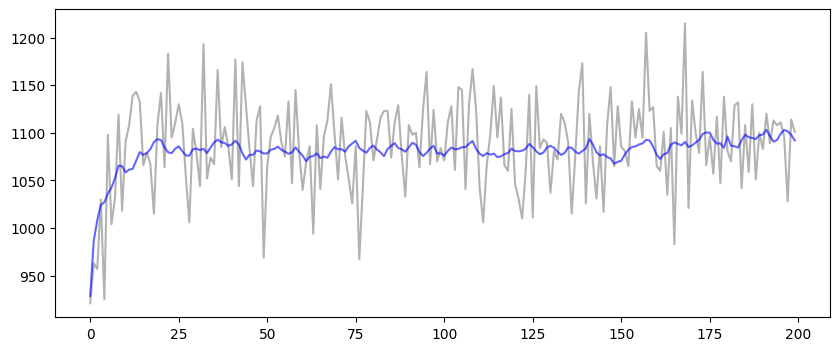

In [29]:
noisy_video_scaled = video_tensor
tucker_video_scaled = best_reconstruction
denoised_video_norm = (denoised_video - mean_val) / std_val
final_denoised_video_scaled = denoised_video_norm + tucker_video_scaled
final_denoised_video_scaled_t = final_denoised_video_scaled * std_val + mean_val




denoised_video_trace = final_denoised_video_scaled[:, x, y]
tucker_t = tucker_video_scaled[:, x, y]
f = final_denoised_video_scaled_t[:, x, y]


plt.figure(figsize=(10, 4))
plt.plot(raw_trace.cpu(), label='Noisy', color='gray', alpha=0.6)
plt.plot(f.cpu(), label='denoised', color='blue', alpha=0.6)



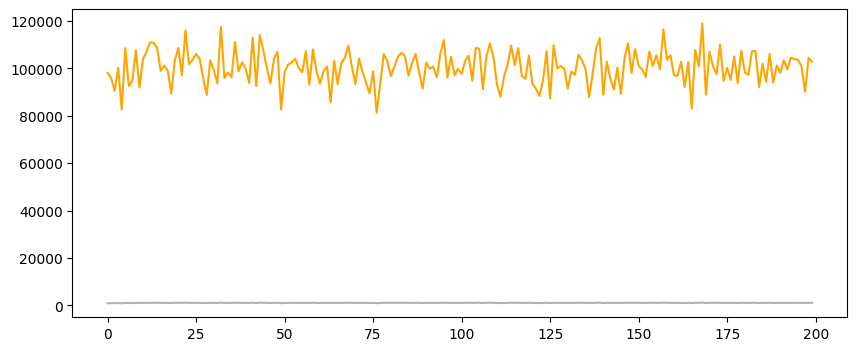

C:\Users\SUJATHA\AppData\Local\Temp\ipykernel_14600\193239253.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  denoised_video = torch.tensor(denoised_video, dtype=torch.float32)


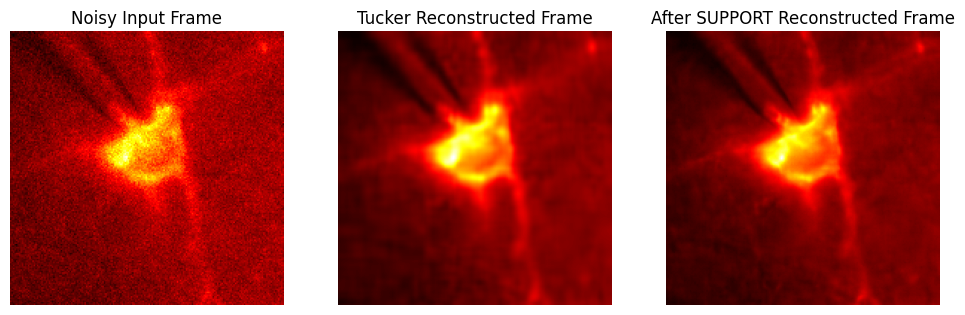

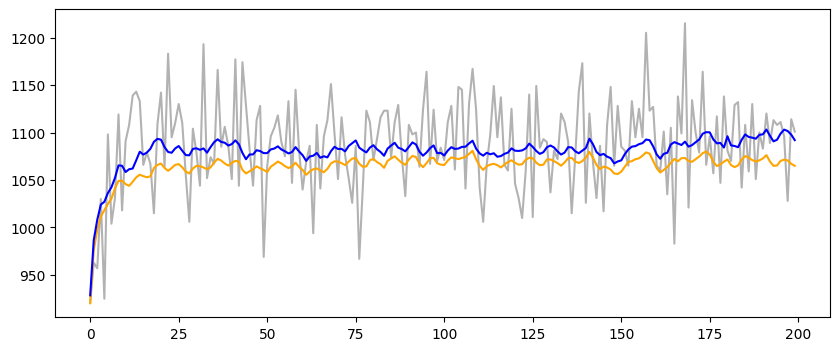

In [31]:
denoised_video = torch.tensor(denoised_video, dtype=torch.float32)

noisy_video_scaled = video_tensor * std_val + mean_val
tucker_video_scaled = best_reconstruction * std_val + mean_val
denoised_video_norm = (denoised_video - mean_val) / std_val
final_denoised_video_norm = denoised_video_norm + best_reconstruction
final_denoised_video_scaled = final_denoised_video_norm * std_val + mean_val

noisy_frame = noisy_video_scaled[frame_idx].detach().cpu().numpy()
tucker_frame = tucker_video_scaled[frame_idx].detach().cpu().numpy()
final_frame = final_denoised_video_scaled[frame_idx].detach().cpu().numpy()
fig, axs = plt.subplots(1, 3, figsize=(12, 4))
axs[0].imshow(noisy_frame, cmap='hot')
axs[0].set_title('Noisy Input Frame')
axs[0].axis('off')

axs[1].imshow(tucker_frame, cmap='hot')
axs[1].set_title('Tucker Reconstructed Frame')
axs[1].axis('off')

axs[2].imshow(final_frame, cmap='hot')
axs[2].set_title('After SUPPORT Reconstructed Frame')
axs[2].axis('off')

raw_trace = noisy_video_scaled[:, x, y]
tucker_trace = tucker_video_scaled[:, x, y]
final_trace = final_denoised_video_scaled[:, x, y]

plt.figure(figsize=(10, 4))
plt.plot(raw_trace.cpu(), label='Noisy', color='gray', alpha=0.6)
plt.plot(tucker_trace.cpu(), label='Tucker Denoised', color='orange')
plt.plot(final_trace.cpu(), label='SUPPORT Denoised', color='blue')

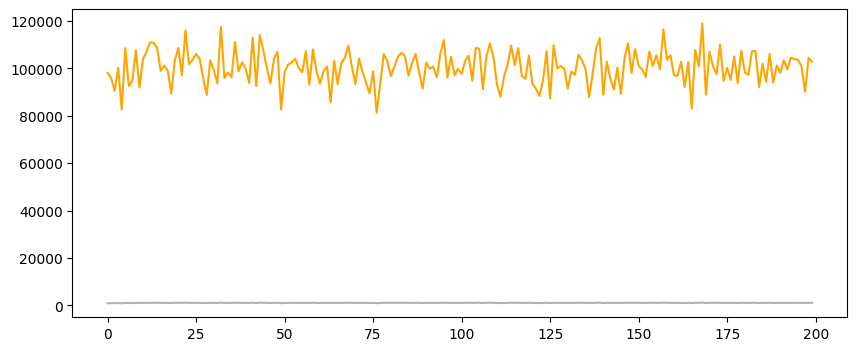

In [13]:
residual_trace = residual_image[:, x, y] * std_val + mean_val
raw_trace = video_tensor[:, x, y] * std_val + mean_val

plt.figure(figsize=(10, 4))
plt.plot(raw_trace.cpu(), label='Noisy', color='gray', alpha=0.6)
plt.plot(residual_trace.cpu(), label='residual', color='orange')

SUPPORT Denoising:   0%|          | 0/200 [00:00<?, ?frame/s]

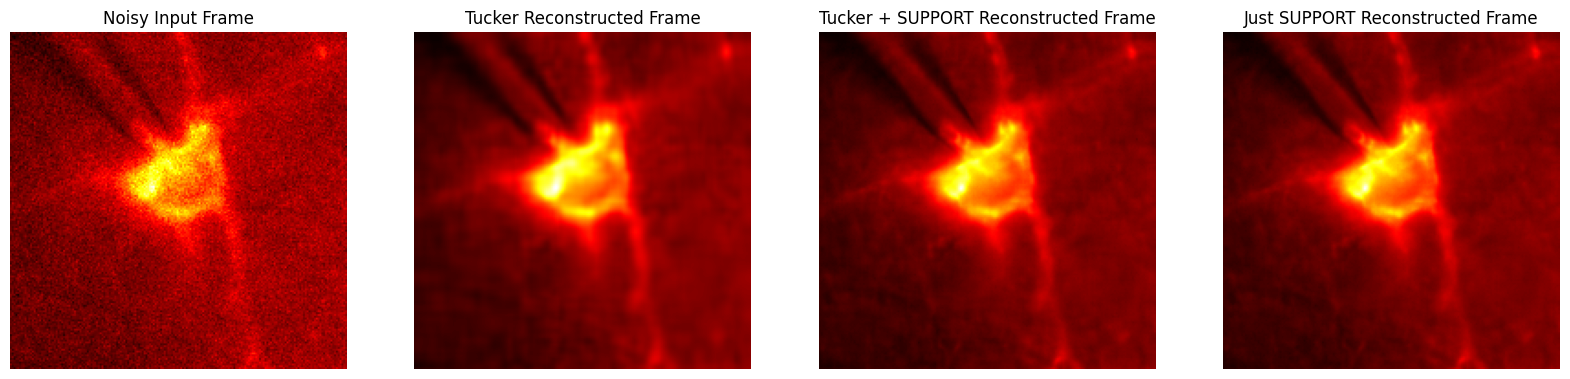

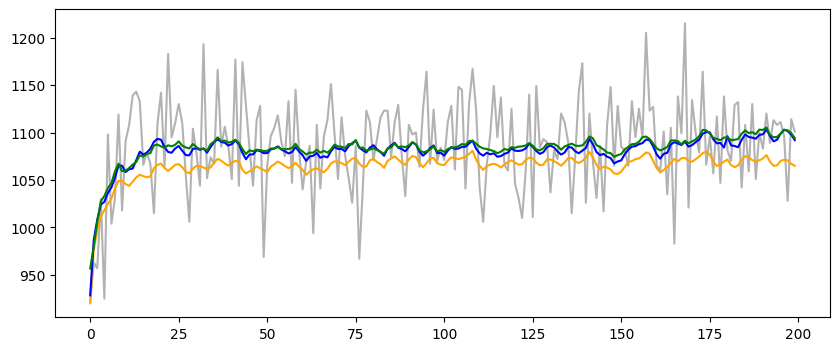

In [33]:
video_tensor_scaled = video_tensor * std_val + mean_val 

model_path = "E:\\Denoising\\SUPPORT\\src\\GUI\\trained_models\\zebrafish_voltage.pth"
support_model = load_support_model(model_path, bs_size=1, use_cuda=False)

# Compute mean/std from first window
mean_one = mean_val.item()
std_one = std_val.item()

# Denoise all frames
denoised_video = np.zeros_like(video_tensor_scaled, dtype=np.float32)

for ti in tqdm(range(T), desc="SUPPORT Denoising", unit="frame"):
    denoised_video[ti] = run_support_model_on_frame(
        video_tensor_scaled, ti, support_model, mean_one, std_one, use_cuda=False
    )

denoised_video_just_support = torch.tensor(denoised_video, dtype=torch.float32)

denoised_video_just_support_frame = denoised_video_just_support[frame_idx].detach().cpu().numpy()


fig, axs = plt.subplots(1, 4, figsize=(20, 5))
axs[0].imshow(noisy_frame, cmap='hot')
axs[0].set_title('Noisy Input Frame')
axs[0].axis('off')

axs[1].imshow(tucker_frame, cmap='hot')
axs[1].set_title('Tucker Reconstructed Frame')
axs[1].axis('off')

axs[2].imshow(final_frame, cmap='hot')
axs[2].set_title('Tucker + SUPPORT Reconstructed Frame')
axs[2].axis('off')

axs[3].imshow(denoised_video_just_support_frame, cmap='hot')
axs[3].set_title('Just SUPPORT Reconstructed Frame')
axs[3].axis('off')

raw_trace = noisy_video_scaled[:, x, y]
tucker_trace = tucker_video_scaled[:, x, y]
final_trace = final_denoised_video_scaled[:, x, y]
final_trace_support = denoised_video_just_support[:, x, y]

plt.figure(figsize=(10, 4))
plt.plot(raw_trace.cpu(), label='Noisy', color='gray', alpha=0.6)
plt.plot(tucker_trace.cpu(), label='Tucker Denoised', color='orange')
plt.plot(final_trace.cpu(), label='SUPPORT Denoised', color='blue')
plt.plot(final_trace_support.cpu(), label='Just SUPPORT Denoised', color='green')

